In [1]:
import pandas as pd

# Cargamos los datasets para inspeccionarlos
orders = pd.read_parquet('../../data/raw/orders.parquet')
users = pd.read_parquet('../../data/raw/users.parquet')
inventory = pd.read_parquet('../../data/raw/inventory.parquet')

# 1. Sanity Check: Tamaño y tipos
print(f"Dimensiones de pedidos: {orders.shape}") #
print(f"Dimensiones de usuarios: {users.shape}")
print(orders.dtypes) #

# 2. Revision de Nulos (Missing Values)
# Buscamos si faltan datos importantes como IDs de usuario o productos
print("\nValores nulos por columna:")
print(orders.isnull().sum()) #

# 3. Visualización rápida
orders.head()

Dimensiones de pedidos: (8773, 6)
Dimensiones de usuarios: (4983, 10)
id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object
dtype: object

Valores nulos por columna:
id                0
user_id           0
created_at        0
order_date        0
user_order_seq    0
ordered_items     0
dtype: int64


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [5]:
# Join especificando columnas con nombres distintos
# 'left_on' es la columna de Pedidos y 'right_on' la de Inventario
orders_with_info = orders_exploded.merge(
    inventory, 
    left_on='item_id', 
    right_on='variant_id', 
    how='left'
)

# 1. Check de integridad: ¿Hay productos vendidos sin info en inventario?
# Usamos 'vendor' o 'product_type' para verificar si el join trajo datos
nulos_tras_join = orders_with_info['product_type'].isnull().sum()
print(f"Productos vendidos que NO estan en el inventario: {nulos_tras_join}")

# 2. Análisis del negocio: ¿Qué tipos de productos vendemos mas?
print("\nTop 5 tipos de productos mas vendidos:")
print(orders_with_info['product_type'].value_counts().head(5))

# 3. Análisis de vendedores (Vendors)
print("\nTop 5 vendedores con mas exito:")
print(orders_with_info['vendor'].value_counts().head(5))

Productos vendidos que NO estan en el inventario: 15597

Top 5 tipos de productos mas vendidos:
product_type
cleaning-products                  9676
tins-packaged-foods                8959
long-life-milk-substitutes         6637
toilet-roll-kitchen-roll-tissue    6314
dishwashing                        4362
Name: count, dtype: int64

Top 5 vendedores con mas exito:
vendor
oatly     5345
ecover    3445
method    3293
fairy     3188
biona     2184
Name: count, dtype: int64


Estadisticas de compra por usuario:
count    4983.000000
mean       21.665262
std        30.084024
min         1.000000
25%         9.000000
50%        13.000000
75%        21.000000
max       499.000000
Name: item_id, dtype: float64


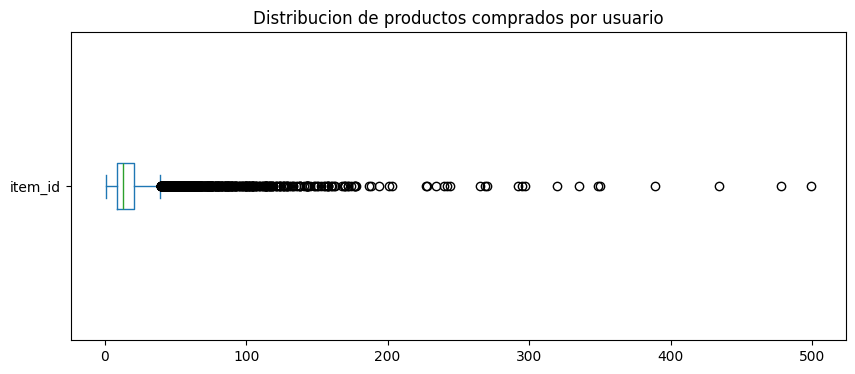


Power Users (Posibles Outliers):
user_id
a655b992a3ee5f6aa9f5ab5662c4befac1fdc45c99885b173618b661ca7381c383b1364e977c9f51366cdc62e4d92ff383e8e5aac7ea9a552059be2671de24e2    499
b9452236b95ed2b60d18404a1e8b5aa4652bc3c4518a6ebd205e82478f657f0b874d90b98710d6cea7eb3c3d8ac7309687e12a34ec2a4f26cc7015df6c09d0a5    478
1296e1e72f7f43ff28d7d285f880ad4d213fa8139233c78ad2673af4cc0c1c297180254da494cc3b934858347822be437eeb072acb1403e9476dc0b2f6a83cbe    434
Name: item_id, dtype: int64


In [6]:
import matplotlib.pyplot as plt

# 1. Calculamos cuantos productos compra cada usuario en total
user_behavior = orders_with_info.groupby('user_id')['item_id'].count().sort_values(ascending=False)

print("Estadisticas de compra por usuario:")
print(user_behavior.describe()) #

# 2. Visualizacion de Outliers con un Boxplot
plt.figure(figsize=(10, 4))
user_behavior.plot(kind='box', vert=False)
plt.title('Distribucion de productos comprados por usuario')
plt.show()

# 3. ¿Quienes son los 3 usuarios que mas compran?
print("\nPower Users (Posibles Outliers):")
print(user_behavior.head(3))

In [9]:
# Verificacion de integridad referencial entre pedidos y usuarios
ids_pedidos = set(orders['user_id'].unique())
ids_maestros = set(users['user_id'].unique())

huerfanos = ids_pedidos - ids_maestros

print(f"Total usuarios en pedidos: {len(ids_pedidos)}")
print(f"Total usuarios en tabla 'users': {len(ids_maestros)}")
print(f"Usuarios sin ficha tecnica: {len(huerfanos)}")

Total usuarios en pedidos: 4983
Total usuarios en tabla 'users': 4983
Usuarios sin ficha tecnica: 0


In [11]:
import os

# Definición de la ruta para datos procesados
processed_dir = '../../data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Limpieza final de columnas antes de exportar
if 'variant_id' in orders_with_info.columns:
    orders_with_info = orders_with_info.drop(columns=['variant_id'])

# Guardado en formato parquet para mantener tipos de datos
orders_with_info.to_parquet(f'{processed_dir}/orders_full_cleaned.parquet')

print(f"Dataset procesado guardado en: {processed_dir}/orders_full_cleaned.parquet")

Dataset procesado guardado en: ../../data/processed/orders_full_cleaned.parquet


In [12]:
import pandas as pd

print("--- REVISIÓN DE REGULARS Y ABANDONED CARTS ---")
regulars = pd.read_parquet('../../data/raw/regulars.parquet')
abandoned = pd.read_parquet('../../data/raw/abandoned_carts.parquet')

print(f"Dimensiones regulars: {regulars.shape}")
print(f"Dimensiones abandoned_carts: {abandoned.shape}")
print(f"Nulos en regulars:\\n{regulars.isnull().sum()}\\n")
print(f"Nulos en abandoned_carts:\\n{abandoned.isnull().sum()}\\n")


# --- FEATURE FRAME ---
print("--- PARTE 2: EXPLORATORY DATA ANALYSIS (CSV) ---")


features = pd.read_csv('../../data/raw/feature_frame.csv')

print(f"Dimensiones del dataset de features: {features.shape}")
print(f"Valores nulos en la variable objetivo 'outcome': {features['outcome'].isnull().sum()}")

print("\\nDistribución de la variable objetivo 'outcome' (%):")
print(features['outcome'].value_counts(normalize=True) * 100)

--- REVISIÓN DE REGULARS Y ABANDONED CARTS ---
Dimensiones regulars: (18105, 3)
Dimensiones abandoned_carts: (5457, 4)
Nulos en regulars:\nuser_id       0
variant_id    0
created_at    0
dtype: int64\n
Nulos en abandoned_carts:\nid            0
user_id       0
created_at    0
variant_id    0
dtype: int64\n
--- PARTE 2: EXPLORATORY DATA ANALYSIS (CSV) ---
Dimensiones del dataset de features: (2880549, 27)
Valores nulos en la variable objetivo 'outcome': 0
\nDistribución de la variable objetivo 'outcome' (%):
outcome
0.0    98.846331
1.0     1.153669
Name: proportion, dtype: float64


# Conclusiones Ejecutivas: Análisis Exploratorio de Datos (EDA)

Tras realizar la interrogación de los datos y los *sanity checks* correspondientes a las distintas fuentes de información, se extraen las siguientes conclusiones clave para el negocio y el posterior modelado:

### 1. Calidad e Integridad de los Datos (Data Quality & Sanity Checks)
* **Alta fiabilidad en transacciones:** Las tablas principales de negocio (`orders`, `regulars`, `abandoned_carts` y `users`) presentan una limpieza excepcional con **0 valores nulos**. Además, existe una **integridad referencial del 100%** entre los pedidos y la base de usuarios registrados.
* **Alerta de Integridad en el Catálogo:** Al cruzar las ventas con la tabla `inventory`, se detectan **15.597 registros huérfanos** (productos vendidos sin información en el inventario). 
    * *Hipótesis:* El archivo de inventario proporcionado es una foto actual que no incluye productos descatalogados o históricos.

### 2. Espacio del Problema y Perfil de Negocio (Domain Knowledge)
* **Nicho de mercado definido:** El análisis del top de ventas (`cleaning-products`, `tins-packaged-foods`, `long-life-milk-substitutes`) y de los principales vendedores (Oatly, Ecover, Method) revela que este e-commerce de alimentación está fuertemente posicionado en el nicho de la **sostenibilidad y alternativas ecológicas/vegetales**.
* **Segmentación B2C vs B2B (Análisis de Outliers):** La distribución del tamaño de la cesta está muy sesgada a la derecha. Aunque el cliente mediano compra 13 artículos, existen "Power Users" (outliers extremos) que adquieren hasta **499 productos por pedido**. 
    * *Hipótesis:* La plataforma está sirviendo simultáneamente a clientes particulares (B2C) y a pequeños negocios o restauración (B2B), lo cual deberá tenerse en cuenta para futuras estrategias de retención o recomendación.

### 3. Análisis del Dataset de Características (Box Builder / Feature Frame)
* **Dimensionamiento:** El dataset preprocesado para modelado (`feature_frame.csv`) tiene un volumen robusto de **~2.88 millones de observaciones** y 27 variables predictoras.
* **Insight Crítico para el Modelado (Data Imbalance):** La variable objetivo (`outcome`) presenta un desbalanceo de clases extremo. Únicamente el **1.15%** de los registros resultan en una compra (clase positiva), frente al 98.85% de rechazos (clase negativa). 
    * *Impacto:* Para el entrenamiento del futuro modelo predictivo, la "Accuracy" (precisión global) no será una métrica válida. Será imperativo aplicar técnicas de balanceo (ej. *class weights*, *undersampling*) y evaluar el rendimiento mediante métricas como el **F1-Score** o el área bajo la curva Precision-Recall (**PR-AUC**).